# Q1. Forward Propagation
Apply forward propagation on the given dataset or implement forward propagation for a single perceptron using the given inputs, weights, and bias.

In [1]:
# Forward Propagation

x1 = 2
x2 = 3

w1 = 0.5
w2 = 0.4

b = 0.1

# Calculate weighted sum
z = (x1 * w1) + (x2 * w2) + b

# Step activation function
if z >= 0:
    output = 1
else:
    output = 0

print("Weighted Sum:", z)
print("Predicted Output:", output)

Weighted Sum: 2.3000000000000003
Predicted Output: 1


# Q2:MLP and Vanishing Gradient Problem
Write a Python program to create a Multi-Layer Perceptron (MLP) architecture and demonstrate the vanishing gradient problem.

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(10, activation="sigmoid", input_shape=(4,)),
    Dense(10, activation="sigmoid"),
    Dense(10, activation="sigmoid"),
    Dense(3, activation="softmax")
])

model.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 303 (1.18 KB)

 Trainable params: 303 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3250 - loss: 1.3722 
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3250 - loss: 1.3472
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3250 - loss: 1.3245
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3250 - loss: 1.3033
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3250 - loss: 1.2848 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3250 - loss: 1.2672 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3250 - loss: 1.2520 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.2378 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.2252 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3250 - loss: 1.2134


In [5]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.3667 - loss: 1.1603
Test Accuracy: 0.36666667461395264


# Q3:Batch Normalization
Apply Batch Normalization to an MLP architecture and evaluate its performance by comparing the model accuracy before and after applying Batch Normalization.

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.fit(X_train, y_train, epochs=20, verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Accuracy without Batch Normalization:", acc1)

Accuracy without Batch Normalization: 0.9666666388511658


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

model2 = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    BatchNormalization(),
    Dense(16, activation="relu"),
    BatchNormalization(),
    Dense(3, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Accuracy with Batch Normalization:", acc2)

Accuracy with Batch Normalization: 1.0


In [9]:
print("Without Batch Normalization:", acc1)
print("With Batch Normalization:", acc2)

Without Batch Normalization: 0.9666666388511658
With Batch Normalization: 1.0


# Q4. Node Dropout
Apply Node Dropout to an MLP architecture and compare the model performance and accuracy before and after applying Dropout.

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.fit(X_train, y_train, epochs=30, verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Accuracy without Dropout:", acc1)

Accuracy without Dropout: 0.8333333134651184


In [12]:
from tensorflow.keras.layers import Dropout

model2 = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dropout(0.5),
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.fit(X_train, y_train, epochs=30, verbose=0)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Accuracy with Dropout:", acc2)

Accuracy with Dropout: 0.699999988079071


In [13]:
print("Without Dropout:", acc1)
print("With Dropout:", acc2)

Without Dropout: 0.8333333134651184
With Dropout: 0.699999988079071


# Q5. Iris Dataset with MLP
Load the Iris dataset, apply an MLP model for classification, and evaluate the model using appropriate evaluation metrics.

In [14]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (150, 4)
Y shape: (150,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=40, verbose=0)

In [18]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8666666746139526


In [19]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.56      0.71         9
           2       0.73      1.00      0.85        11

    accuracy                           0.87        30
   macro avg       0.91      0.85      0.85        30
weighted avg       0.90      0.87      0.86        30



# Q6. Data Encoding
Apply appropriate encoding techniques to different types of datasets based on the type of data and classification problem.

In [20]:
import pandas as pd

data = {
    "Gender": ["Male", "Female", "Male", "Female"],
    "City": ["Ahmedabad", "Surat", "Ahmedabad", "Rajkot"],
    "Result": ["Pass", "Fail", "Pass", "Pass"]
}

df = pd.DataFrame(data)

print(df)

   Gender       City Result
0    Male  Ahmedabad   Pass
1  Female      Surat   Fail
2    Male  Ahmedabad   Pass
3  Female     Rajkot   Pass


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Result"] = le.fit_transform(df["Result"])

print(df)

   Gender       City  Result
0       1  Ahmedabad       1
1       0      Surat       0
2       1  Ahmedabad       1
3       0     Rajkot       1


In [22]:
df = pd.get_dummies(df, columns=["City"])

print(df)

   Gender  Result  City_Ahmedabad  City_Rajkot  City_Surat
0       1       1            True        False       False
1       0       0           False        False        True
2       1       1            True        False       False
3       0       1           False         True       False


# Q7. CNN on MNIST Dataset
Load the MNIST dataset and develop a Convolutional Neural Network (CNN) model. Resize and normalize the images, apply Convolutional, Pooling, Flatten, and Dense layers, train and test the model, calculate training and testing accuracy, and plot the training and validation accuracy curves.

In [23]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [24]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9534 - loss: 0.1562 - val_accuracy: 0.9845 - val_loss: 0.0585
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9841 - loss: 0.0521 - val_accuracy: 0.9848 - val_loss: 0.0531
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9870 - val_loss: 0.0448
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9932 - loss: 0.0218 - val_accuracy: 0.9853 - val_loss: 0.0563
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9950 - loss: 0.0150 - val_accuracy: 0.9858 - val_loss: 0.0594


In [28]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9928666949272156
Testing Accuracy: 0.9825999736785889


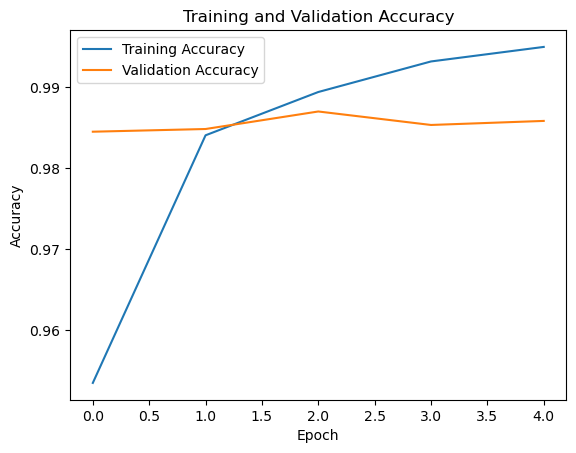

In [29]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Q8. Take an appropriate image classification dataset and develop a CNN model. Perform image preprocessing, including resizing and normalization, followed by Convolutional, Pooling, Flatten, and Dense layers. Train the model, evaluate its training and testing accuracy, and plot the training and validation accuracy and loss curves.

In [30]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [31]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2609s 15us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [32]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Preprocessing completed")

Preprocessing completed


In [33]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.4880 - loss: 1.4294 - val_accuracy: 0.5948 - val_loss: 1.1607
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6225 - loss: 1.0749 - val_accuracy: 0.6416 - val_loss: 1.0217
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6759 - loss: 0.9263 - val_accuracy: 0.6728 - val_loss: 0.9276
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7127 - loss: 0.8274 - val_accuracy: 0.7080 - val_loss: 0.8722
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7432 - loss: 0.7344 - val_accuracy: 0.6976 - val_loss: 0.8734


In [35]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.7731000185012817
Testing Accuracy: 0.6845999956130981


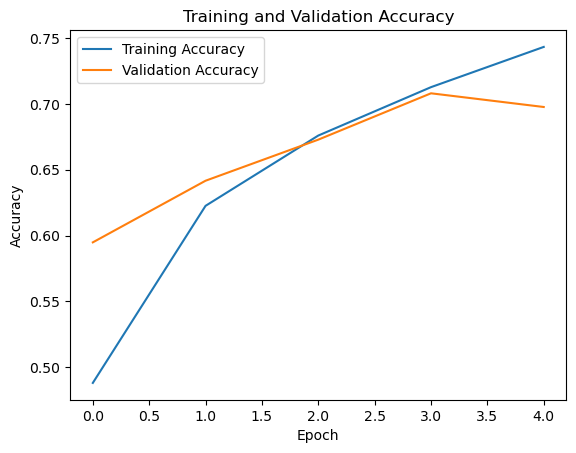

In [36]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

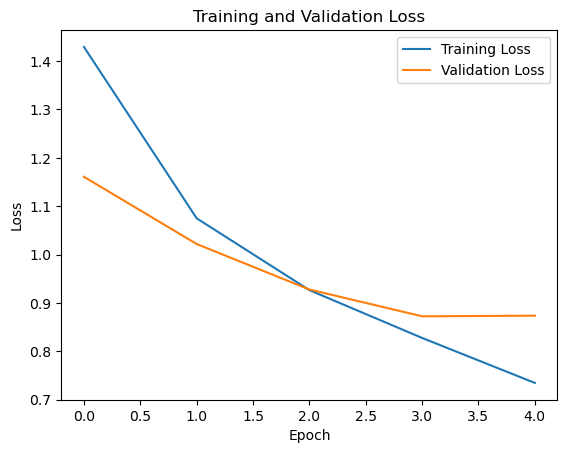

In [37]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()